# Estudio y comparativa resultados distributed + neg out y high fixed

En este notebook vamos a analizar los resultados de la versión distribuida basada en complejidad que incluye la opción de ir quitando las variables con complejidad negativa (con un margen de tolerancia) y de ir fijando las que tienen un valor alto de complejidad. Este valor alto de complejidad es difícil de establecer porque siempre son valores bajitos y además varían en función de la medida de complejidad. Así, por ahora (y por temas computacionales) solo estamos ejecutando para kDN y fijándonos en sus valores. Además, debido a que es "más seguro" que las negativas son malas, damos más fuerza a esto. Es decir, si una variable toma valores negativos, se saca aunque previamente se hubiera fijado. Una vez tomas algún valor negativo estás totalmente fuera y no puedes volver a entrar. Pero si se fija la variable, sí puede volver a salir. Digamos que sacamos variables con más fuerza para ir limpiando.

En base a los resultados del notebook "Distributed_FS_Complexity_Analysis", ya solo aplicamos un método a la hora de obtener los resultados. Se ejecuta únicamente la opción "random choice". Luego el método es: tomar muestras bootstrap de variables e ir evaluando la complejidad siguiendo un esquema backward. La variable que sale en cada caso se escoge de manera aleatoria.

Aquí vamos tanto a estudiar los resultados de esta versión distribuida como a comparar su performance tanto en complejidad como en rendimiento con los métodos del SOTA. En todos los casos vamos a escoger el número k de variables como el número de variables informativas (sabemos cuál es porque estamos en el caso artificial). En nuestra versión distribuida hemos hecho un filtro previo de variables con correlación de Pearson superior a 0.9. Así, para que las comparaciones sean justas, hemos ejecutado los métodos del estado del arte tanto sin el filtro como con el filtro. Los métodos del SOTA con filtro tendrán un "_corr" en el nombre.

In [1]:
import copy
from sklearn import preprocessing
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from skrebate import ReliefF
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import glob
import re
from DistributedFS_Complexity import *

In [2]:
import os
os.chdir("..")
root_path = os.getcwd()

### Resultados distributed

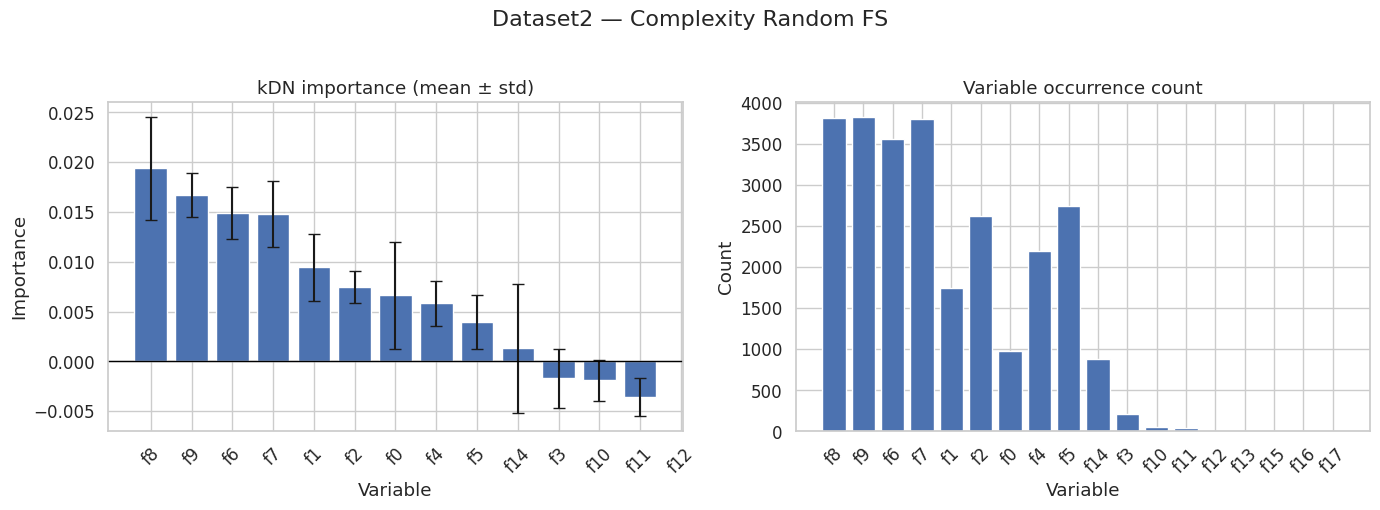

In [3]:
# Dataset 2
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset2_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset2")

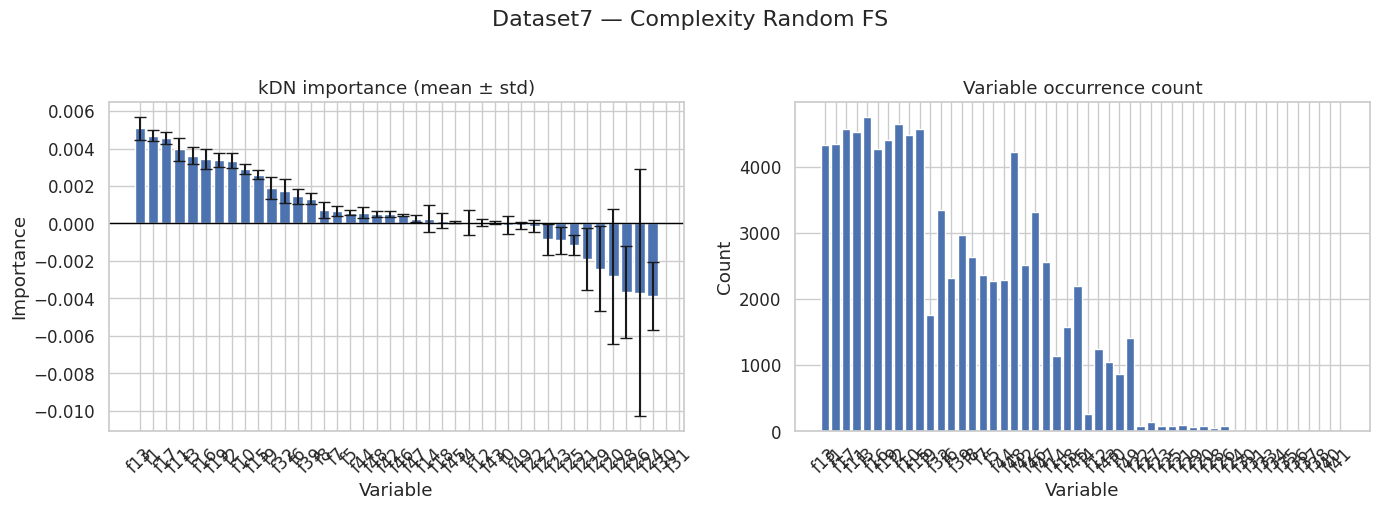

In [4]:
# Dataset  7
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset7_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset7")

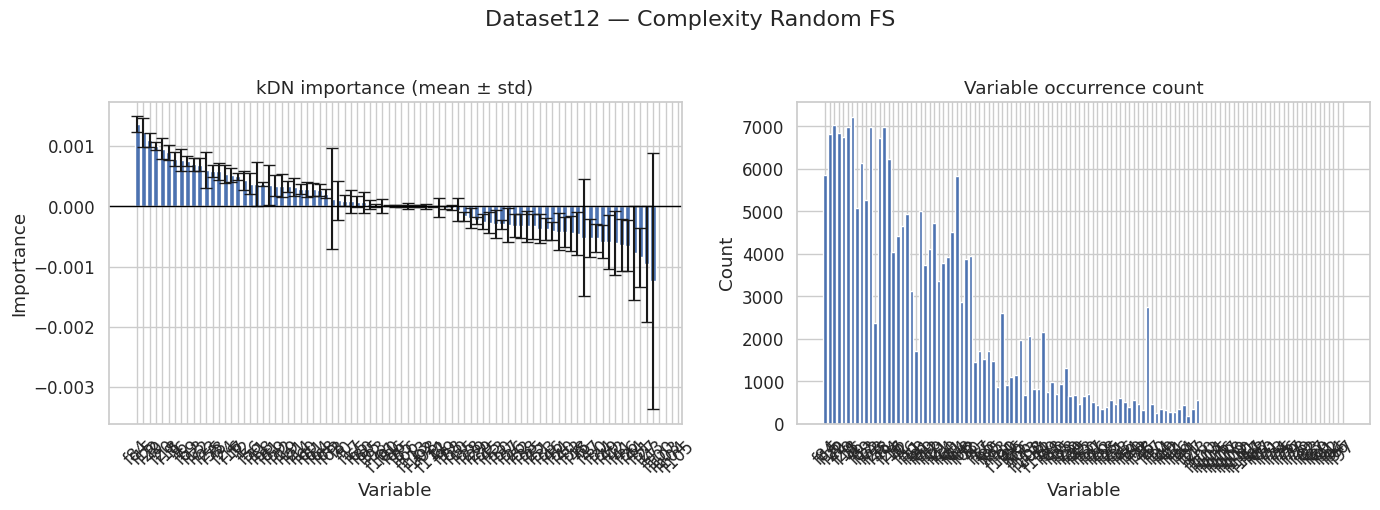

In [5]:
# Dataset 12
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset12_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset12")

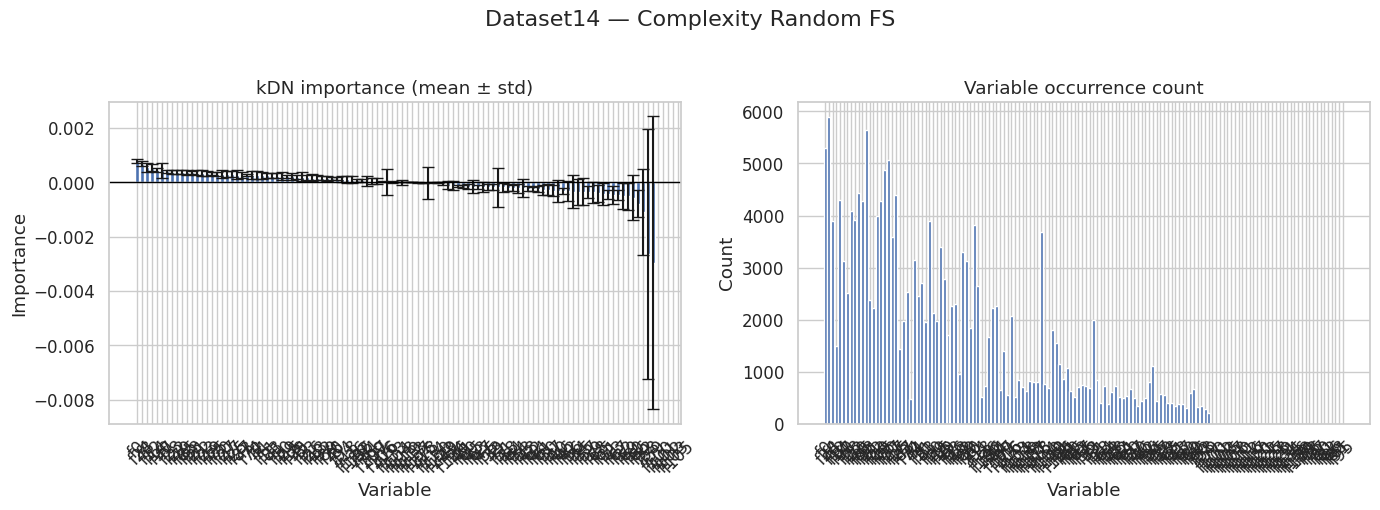

In [6]:
# # Dataset 14
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset14_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset14")

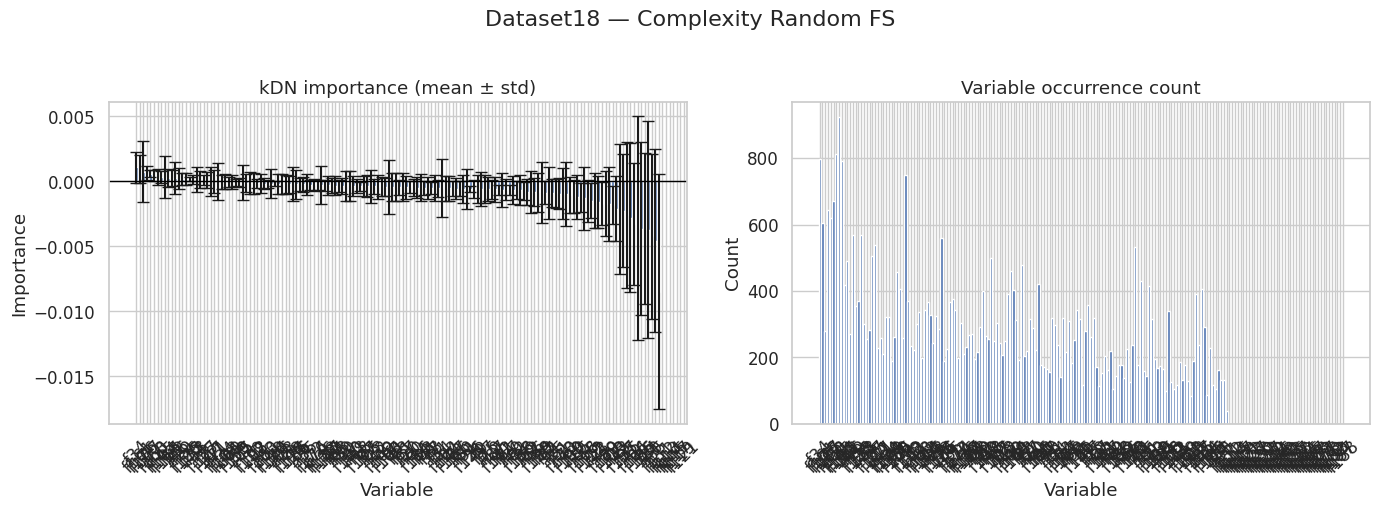

In [7]:
# # Dataset 18
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset18_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset18")

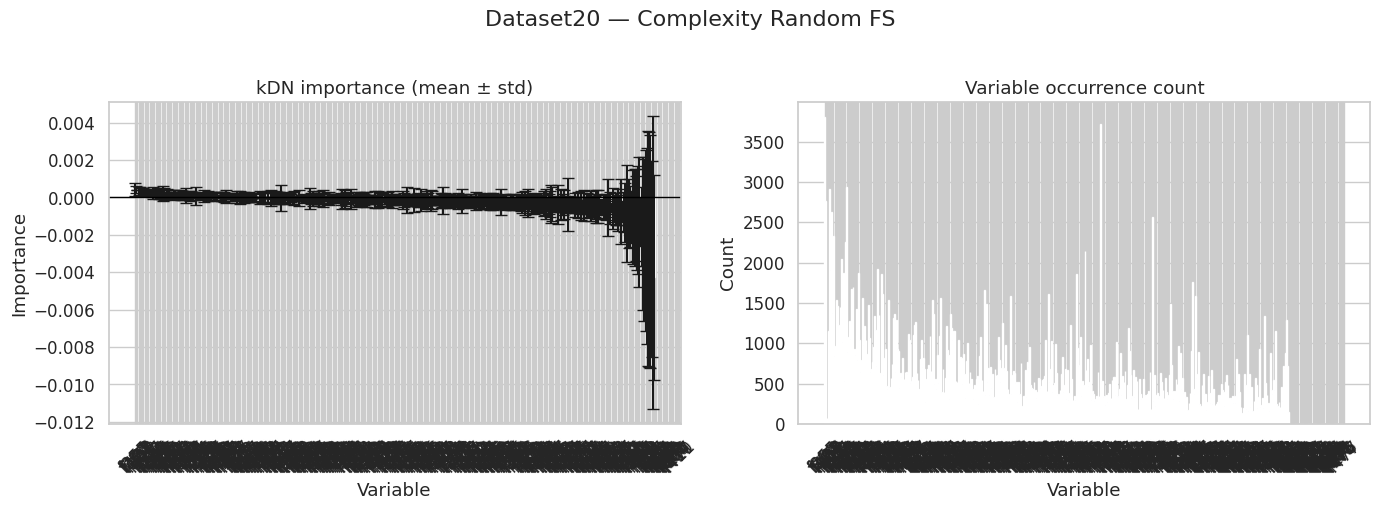

In [8]:
# # Dataset 20
df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset20_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)

plot_complexity_importances_by_model(df_random, dataset_name="Dataset20")

In [16]:
# # Dataset 21
# df_random = pd.read_csv("Results_FS_Distributed_CV/ArtificialDataset21_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv", index_col=0)
#
# plot_complexity_importances_by_model(df_random, dataset_name="Dataset21")

VER CUÁLES SON SIEMPRE POSITIVAS Y ANALIZAR CÓMO VA LA PERFORMANCE SOLO CON ELLAS, sacar cuántas son prositivas, corr entre modelos del ranking y relacionar el número de positivas con el número de informativas

## Tabla de comparación SOTA vs distributed (backward)

In [4]:
# Leer todos los comparison.csv de la carpeta
files = glob.glob("Results_ComparisonDistributed_SOTA/*_ComparisonTable_CV_neg_high.csv")

all_tables = []
for f in files:
    df = pd.read_csv(f, index_col=[1])
    all_tables.append(df)

comparison_all = pd.concat(all_tables)
comparison_all.head()

,dataset,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
method,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset12,KNN,0.869250,0.005115,0.826667,0.016287,0.863851,0.005390,0.818657,0.017387,0.172833,0.008506,0.248005,0.007225,0.264417,0.003261,115.0,Subsets,NaN
informative,ArtificialDataset12,KNN,0.886667,0.004705,0.863000,0.013509,0.882026,0.004995,0.856624,0.014508,0.142000,0.006779,0.215803,0.004316,0.235567,0.003247,25.0,Subsets,NaN
informative+redundant,ArtificialDataset12,KNN,0.886500,0.003687,0.854667,0.011926,0.881739,0.003946,0.848202,0.012947,0.151750,0.005484,0.224603,0.009909,0.246183,0.002284,55.0,Subsets,NaN
informative+redundant_nonLinear,ArtificialDataset12,KNN,0.880333,0.002346,0.839333,0.010314,0.875263,0.002406,0.831322,0.012045,0.155167,0.004909,0.235251,0.006837,0.253833,0.002867,55.0,Subsets,NaN
informative+rand_extra,ArtificialDataset12,KNN,0.884667,0.002383,0.859000,0.012834,0.879932,0.002649,0.852287,0.014469,0.143833,0.008288,0.218620,0.003894,0.239783,0.003165,28.0,Subsets,NaN


In [10]:
display(comparison_all.loc[comparison_all['dataset']=='ArtificialDataset2'])

,dataset,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
method,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset2,KNN,0.96800,0.004202,0.935,0.018708,0.967999,0.004203,0.934975,0.018704,0.10400,0.010731,0.105563,0.009939,0.13770,0.006024,18.0,Subsets,NaN
informative,ArtificialDataset2,KNN,0.97175,0.002271,0.953,0.015652,0.971749,0.002271,0.952973,0.015674,0.08250,0.011524,0.077143,0.004044,0.11645,0.006004,10.0,Subsets,NaN
informative+redundant,ArtificialDataset2,KNN,0.96800,0.001896,0.949,0.015969,0.967999,0.001896,0.948961,0.016008,0.08700,0.011131,0.095342,0.004136,0.12325,0.006757,14.0,Subsets,NaN
informative+redundant_nonLinear,ArtificialDataset2,KNN,0.96775,0.003687,0.949,0.009618,0.967749,0.003687,0.948987,0.009624,0.08750,0.008839,0.089136,0.005768,0.11990,0.003538,12.0,Subsets,NaN
informative+rand_extra,ArtificialDataset2,KNN,0.96600,0.002850,0.935,0.014142,0.965999,0.002851,0.934964,0.014139,0.09350,0.005031,0.103518,0.007235,0.13435,0.003591,13.0,Subsets,NaN
informative+noise,ArtificialDataset2,KNN,0.96425,0.006410,0.928,0.024135,0.964249,0.006411,0.927926,0.024207,0.10475,0.005823,0.101091,0.007033,0.14975,0.008137,12.0,Subsets,NaN
f_classif,ArtificialDataset2,KNN,0.93100,0.013445,0.876,0.024341,0.930984,0.013453,0.875629,0.024619,0.13725,0.022697,0.156500,0.019452,0.19650,0.022862,10.0,SOTA,1.0
mutual_info,ArtificialDataset2,KNN,0.94000,0.019665,0.903,0.029917,0.939991,0.019661,0.902902,0.030016,0.11450,0.032242,0.129508,0.030159,0.16590,0.036263,10.0,SOTA,1.0
relief,ArtificialDataset2,KNN,0.96175,0.005562,0.939,0.025836,0.961748,0.005564,0.938957,0.025876,0.08600,0.019594,0.091967,0.008304,0.12360,0.004347,10.0,SOTA,1.0


In [11]:
display(comparison_all.loc[comparison_all['dataset']=='ArtificialDataset7'])

,dataset,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
method,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset7,KNN,0.99200,0.003708,0.986,0.005477,0.99200,0.003708,0.985998,0.005478,0.02850,0.007573,0.038384,0.006919,0.05815,0.005095,50.0,Subsets,NaN
informative,ArtificialDataset7,KNN,0.99950,0.001118,0.999,0.002236,0.99950,0.001118,0.999000,0.002236,0.01250,0.005000,0.018746,0.003572,0.03070,0.002701,20.0,Subsets,NaN
informative+redundant,ArtificialDataset7,KNN,0.99875,0.001250,0.999,0.002236,0.99875,0.001250,0.999000,0.002236,0.02150,0.006755,0.023459,0.002416,0.03850,0.002404,30.0,Subsets,NaN
informative+redundant_nonLinear,ArtificialDataset7,KNN,0.99550,0.000685,0.992,0.005701,0.99550,0.000685,0.991999,0.005701,0.01900,0.005687,0.022315,0.006686,0.03640,0.002614,30.0,Subsets,NaN
informative+rand_extra,ArtificialDataset7,KNN,0.99800,0.000685,0.996,0.002236,0.99800,0.000685,0.996000,0.002236,0.01525,0.006212,0.023644,0.005568,0.03550,0.002834,23.0,Subsets,NaN
informative+noise,ArtificialDataset7,KNN,0.99175,0.002592,0.986,0.010247,0.99175,0.002592,0.985999,0.010248,0.05075,0.010293,0.050938,0.009226,0.07070,0.006158,30.0,Subsets,NaN
f_classif,ArtificialDataset7,KNN,0.99250,0.002500,0.984,0.008216,0.99250,0.002500,0.983997,0.008218,0.02775,0.013416,0.031693,0.008318,0.04685,0.008856,20.0,SOTA,1.0
mutual_info,ArtificialDataset7,KNN,0.99025,0.003579,0.977,0.013509,0.99025,0.003580,0.976992,0.013521,0.03375,0.009186,0.043888,0.007360,0.05745,0.003452,20.0,SOTA,1.0
relief,ArtificialDataset7,KNN,0.99625,0.001531,0.992,0.002739,0.99625,0.001531,0.991999,0.002739,0.01375,0.004760,0.020670,0.004075,0.03010,0.003291,20.0,SOTA,1.0


In [12]:
display(comparison_all.loc[comparison_all['dataset']=='ArtificialDataset12'])

,dataset,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
method,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset12,KNN,0.869250,0.005115,0.826667,0.016287,0.863851,0.005390,0.818657,0.017387,0.172833,0.008506,0.248005,0.007225,0.264417,0.003261,115.0,Subsets,NaN
informative,ArtificialDataset12,KNN,0.886667,0.004705,0.863000,0.013509,0.882026,0.004995,0.856624,0.014508,0.142000,0.006779,0.215803,0.004316,0.235567,0.003247,25.0,Subsets,NaN
informative+redundant,ArtificialDataset12,KNN,0.886500,0.003687,0.854667,0.011926,0.881739,0.003946,0.848202,0.012947,0.151750,0.005484,0.224603,0.009909,0.246183,0.002284,55.0,Subsets,NaN
informative+redundant_nonLinear,ArtificialDataset12,KNN,0.880333,0.002346,0.839333,0.010314,0.875263,0.002406,0.831322,0.012045,0.155167,0.004909,0.235251,0.006837,0.253833,0.002867,55.0,Subsets,NaN
informative+rand_extra,ArtificialDataset12,KNN,0.884667,0.002383,0.859000,0.012834,0.879932,0.002649,0.852287,0.014469,0.143833,0.008288,0.218620,0.003894,0.239783,0.003165,28.0,Subsets,NaN
informative+noise,ArtificialDataset12,KNN,0.853500,0.004435,0.788667,0.012494,0.846077,0.004514,0.775749,0.014599,0.217083,0.010676,0.294461,0.005155,0.310833,0.001576,55.0,Subsets,NaN
f_classif,ArtificialDataset12,KNN,0.852583,0.005123,0.783667,0.017850,0.845478,0.005533,0.770767,0.019939,0.196833,0.008842,0.274029,0.003831,0.291767,0.003519,25.0,SOTA,1.0
mutual_info,ArtificialDataset12,KNN,0.850333,0.011944,0.792667,0.015617,0.842463,0.012951,0.779802,0.016286,0.193750,0.007977,0.274077,0.016065,0.296117,0.013620,25.0,SOTA,1.0
relief,ArtificialDataset12,KNN,0.880417,0.002811,0.844333,0.014795,0.875286,0.003038,0.836641,0.016572,0.154750,0.002789,0.231594,0.002800,0.246567,0.004064,25.0,SOTA,1.0


In [13]:
display(comparison_all.loc[comparison_all['dataset']=='ArtificialDataset14'])

,dataset,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
method,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset14,KNN,0.847000,0.007468,0.776667,0.011055,0.811450,0.010622,0.711140,0.016232,0.208250,0.012874,0.283925,0.004763,0.309083,0.005071,140.0,Subsets,NaN
informative,ArtificialDataset14,KNN,0.876750,0.004854,0.832333,0.007032,0.854183,0.006601,0.795721,0.007208,0.170083,0.006048,0.249895,0.005596,0.280033,0.003698,30.0,Subsets,NaN
informative+redundant,ArtificialDataset14,KNN,0.876833,0.003640,0.817333,0.012506,0.854110,0.004485,0.776333,0.019650,0.185500,0.012588,0.260658,0.005979,0.292417,0.003716,60.0,Subsets,NaN
informative+redundant_nonLinear,ArtificialDataset14,KNN,0.874083,0.002575,0.815333,0.007583,0.850884,0.003925,0.775469,0.011479,0.195167,0.009676,0.274411,0.006270,0.298617,0.002910,70.0,Subsets,NaN
informative+rand_extra,ArtificialDataset14,KNN,0.873917,0.003871,0.828000,0.008772,0.849642,0.005178,0.788138,0.013329,0.176917,0.007947,0.249072,0.004179,0.284550,0.001725,33.0,Subsets,NaN
informative+noise,ArtificialDataset14,KNN,0.810167,0.007087,0.720333,0.012439,0.756382,0.013073,0.606369,0.026063,0.271917,0.006364,0.341829,0.004129,0.364500,0.003447,70.0,Subsets,NaN
f_classif,ArtificialDataset14,KNN,0.848167,0.002545,0.760667,0.012394,0.818793,0.003265,0.704477,0.022257,0.236750,0.005029,0.304172,0.008838,0.332667,0.005822,30.0,SOTA,1.0
mutual_info,ArtificialDataset14,KNN,0.792333,0.011695,0.686000,0.012053,0.740426,0.017143,0.584281,0.033122,0.275750,0.023906,0.364562,0.012375,0.377467,0.007595,30.0,SOTA,1.0
relief,ArtificialDataset14,KNN,0.850333,0.003968,0.784333,0.015882,0.817913,0.006231,0.722850,0.027603,0.210417,0.008600,0.287064,0.009614,0.309767,0.003513,30.0,SOTA,1.0


In [14]:
display(comparison_all.loc[comparison_all['dataset']=='ArtificialDataset18'])

,dataset,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
method,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset18,KNN,0.7480,0.009421,0.648,0.024900,0.674415,0.017005,0.499687,0.062273,0.3155,0.040597,0.420612,0.019371,0.4300,0.008382,190.0,Subsets,NaN
informative,ArtificialDataset18,KNN,0.7520,0.020494,0.642,0.030332,0.685095,0.031510,0.519529,0.071303,0.3025,0.020233,0.403009,0.023371,0.4187,0.007839,70.0,Subsets,NaN
informative+redundant,ArtificialDataset18,KNN,0.7435,0.010398,0.646,0.011402,0.657937,0.026436,0.490239,0.071445,0.3170,0.012298,0.415181,0.015051,0.4198,0.007396,110.0,Subsets,NaN
informative+redundant_nonLinear,ArtificialDataset18,KNN,0.7445,0.011374,0.642,0.040866,0.669643,0.029635,0.507716,0.047353,0.3220,0.028907,0.409896,0.019312,0.4226,0.009476,110.0,Subsets,NaN
informative+rand_extra,ArtificialDataset18,KNN,0.7595,0.019397,0.644,0.038471,0.693277,0.032576,0.516705,0.071800,0.3235,0.034169,0.393070,0.015712,0.4094,0.009297,73.0,Subsets,NaN
informative+noise,ArtificialDataset18,KNN,0.7615,0.015871,0.628,0.026833,0.694395,0.028465,0.506442,0.039594,0.2995,0.033884,0.397297,0.017678,0.4210,0.005863,110.0,Subsets,NaN
f_classif,ArtificialDataset18,KNN,0.7845,0.019154,0.636,0.005477,0.724463,0.032829,0.471037,0.057748,0.2910,0.020961,0.400800,0.011209,0.4196,0.013926,70.0,SOTA,1.0
mutual_info,ArtificialDataset18,KNN,0.7435,0.024148,0.606,0.028810,0.657860,0.034756,0.400474,0.146896,0.3405,0.023875,0.424625,0.023284,0.4331,0.012075,70.0,SOTA,1.0
relief,ArtificialDataset18,KNN,0.7335,0.024597,0.630,0.010000,0.565900,0.070970,0.260312,0.070890,0.2970,0.022319,0.412718,0.015931,0.4035,0.009035,70.0,SOTA,1.0


In [15]:
display(comparison_all.loc[comparison_all['dataset']=='ArtificialDataset20'])

,dataset,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
method,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset20,KNN,0.9060,0.008023,0.828,0.037014,0.881874,0.011695,0.752651,0.070124,0.2210,0.018422,0.234150,0.018939,0.2912,0.012189,480.0,Subsets,NaN
informative,ArtificialDataset20,KNN,0.9350,0.006124,0.884,0.016733,0.921544,0.007744,0.853148,0.025355,0.1725,0.014684,0.206900,0.024356,0.2568,0.009654,300.0,Subsets,NaN
informative+redundant,ArtificialDataset20,KNN,0.9265,0.016640,0.878,0.019235,0.909067,0.022044,0.838278,0.036078,0.1760,0.011937,0.214573,0.017573,0.2670,0.010914,360.0,Subsets,NaN
informative+redundant_nonLinear,ArtificialDataset20,KNN,0.9250,0.008478,0.862,0.035637,0.908135,0.011253,0.812172,0.061342,0.2145,0.035373,0.225416,0.026145,0.2833,0.009530,360.0,Subsets,NaN
informative+rand_extra,ArtificialDataset20,KNN,0.9315,0.006519,0.888,0.016432,0.916941,0.008404,0.856868,0.029331,0.1655,0.017801,0.197385,0.022148,0.2599,0.012522,303.0,Subsets,NaN
informative+noise,ArtificialDataset20,KNN,0.9120,0.009253,0.858,0.031937,0.892374,0.013136,0.809721,0.060926,0.1925,0.016008,0.229696,0.028352,0.2871,0.006590,360.0,Subsets,NaN
f_classif,ArtificialDataset20,KNN,0.8900,0.009186,0.806,0.023022,0.857372,0.014026,0.703455,0.051657,0.2175,0.013693,0.250804,0.021499,0.3028,0.011471,300.0,SOTA,1.0
mutual_info,ArtificialDataset20,KNN,0.8905,0.014832,0.802,0.051672,0.862690,0.023451,0.703644,0.153229,0.2295,0.032711,0.255122,0.025485,0.3088,0.018134,300.0,SOTA,1.0
relief,ArtificialDataset20,KNN,0.8215,0.009618,0.754,0.027019,0.723554,0.022013,0.521099,0.109317,0.2140,0.030239,0.273495,0.024438,0.2798,0.006834,300.0,SOTA,1.0


In [18]:
display(comparison_all.loc[comparison_all['dataset']=='ArtificialDataset21'])
# En este todavía no se ha ejecutado

,dataset,model,acc_train_mean,acc_train_std,acc_test_mean,acc_test_std,gps_train_mean,gps_train_std,gps_test_mean,gps_test_std,Hostility_mean,Hostility_std,N1_mean,N1_std,kDN_mean,kDN_std,n_features,type,filter_corr
method,,,,,,,,,,,,,,,,,,,
all,ArtificialDataset21,KNN,0.86375,0.009312,0.760,0.012748,0.850722,0.012029,0.722782,0.018796,0.27475,0.024628,0.285775,0.015193,0.35125,0.009901,600.0,Subsets,NaN
informative,ArtificialDataset21,KNN,0.91075,0.007886,0.815,0.022361,0.905202,0.007989,0.798995,0.027648,0.23325,0.010847,0.248273,0.012459,0.31085,0.009593,300.0,Subsets,NaN
informative+redundant,ArtificialDataset21,KNN,0.89500,0.005660,0.797,0.027065,0.887631,0.005702,0.775704,0.038973,0.24275,0.022937,0.260204,0.014137,0.32640,0.007629,400.0,Subsets,NaN
informative+redundant_nonLinear,ArtificialDataset21,KNN,0.88525,0.002710,0.804,0.040528,0.876178,0.002955,0.778898,0.055289,0.25025,0.022851,0.274963,0.025530,0.32740,0.013321,400.0,Subsets,NaN
informative+rand_extra,ArtificialDataset21,KNN,0.90250,0.006495,0.815,0.019685,0.896279,0.006666,0.799265,0.024070,0.22850,0.027047,0.244767,0.012578,0.31280,0.010959,303.0,Subsets,NaN
informative+noise,ArtificialDataset21,KNN,0.88650,0.004793,0.777,0.021966,0.877294,0.006565,0.748725,0.029301,0.23825,0.019052,0.292926,0.011747,0.34340,0.006120,400.0,Subsets,NaN
f_classif,ArtificialDataset21,KNN,0.84425,0.011271,0.710,0.016202,0.828865,0.013322,0.658064,0.029638,0.27475,0.012912,0.322115,0.013766,0.37160,0.012834,300.0,SOTA,1.0
mutual_info,ArtificialDataset21,KNN,0.80775,0.024597,0.675,0.041382,0.781249,0.037194,0.615919,0.043069,0.30575,0.023093,0.378280,0.013875,0.40195,0.011313,300.0,SOTA,1.0
relief,ArtificialDataset21,KNN,0.74700,0.014963,0.655,0.028062,0.657219,0.029963,0.389841,0.121580,0.29250,0.019405,0.326840,0.009522,0.33865,0.001957,300.0,SOTA,1.0


## Performance evolutiva

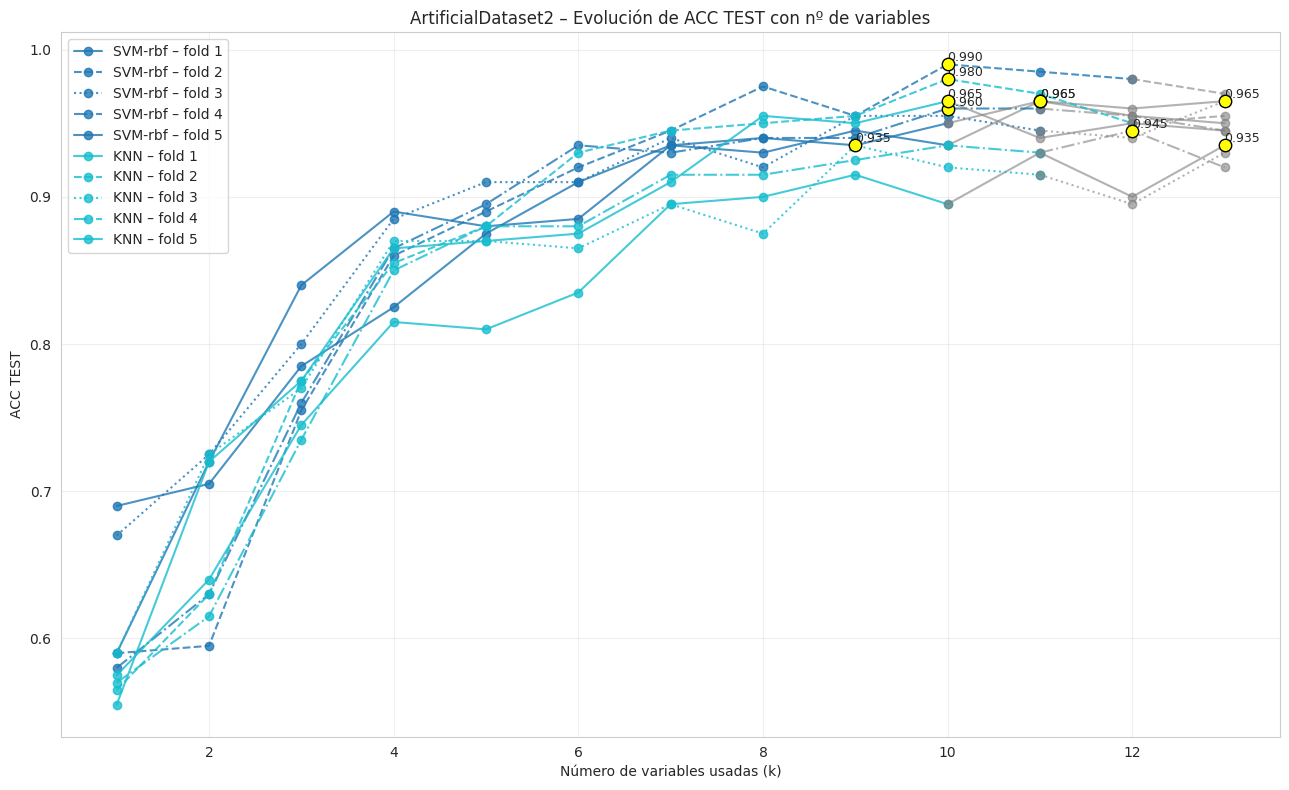

In [7]:
path_csv = 'Results_FS_Distributed_CV/ArtificialDataset2_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv'
importances_dict = load_importances_per_fold(path_csv)
importances_all = pd.concat([v["kDN_importances_norm"] for v in importances_dict.values()],ignore_index=True)

dfs = []
for fold, v in importances_dict.items():
    df = v["kDN_importances_norm"].copy()
    df["fold"] = fold
    dfs.append(df)

importances_all = pd.concat(dfs, ignore_index=True)
perf = pd.read_csv('Results_FS_Distributed_CV/ArtificialDataset2_OutHigh_EvolutivePerformance.csv')

plot_incremental_performance(perf, importances_all,dataset="ArtificialDataset2",measure="acc_test")

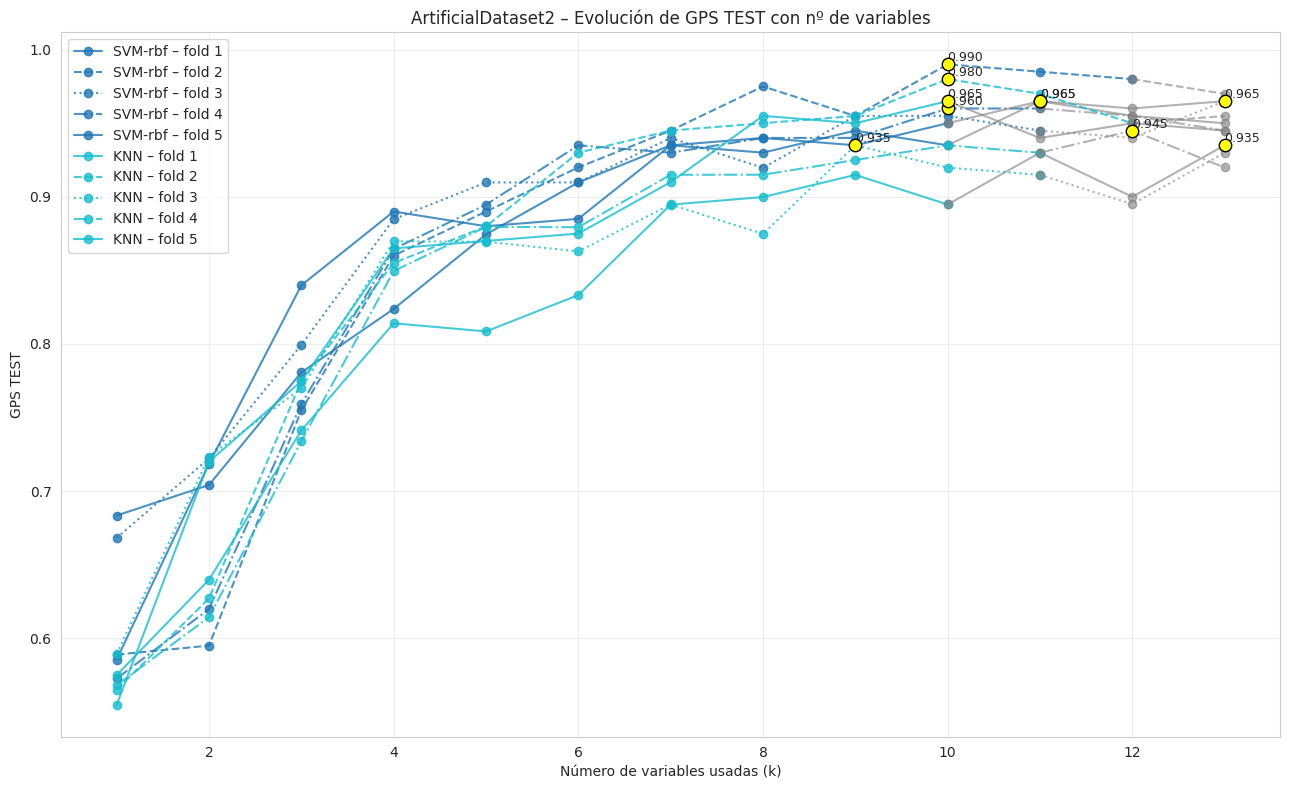

In [8]:
plot_incremental_performance(perf, importances_all,dataset="ArtificialDataset2",measure="gps_test")

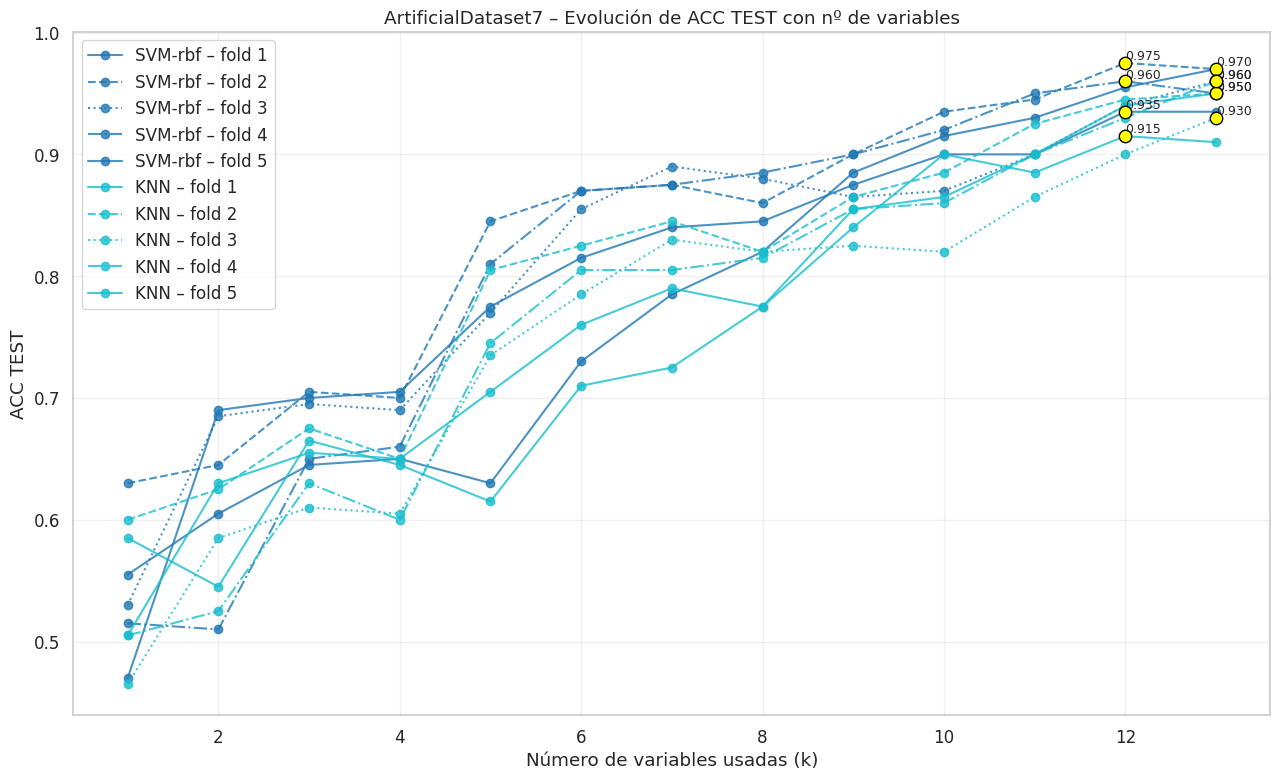

In [9]:
path_csv = 'Results_FS_Distributed_CV/ArtificialDataset7_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv'
importances_dict = load_importances_per_fold(path_csv)
importances_all = pd.concat([v["kDN_importances_norm"] for v in importances_dict.values()],ignore_index=True)

dfs = []
for fold, v in importances_dict.items():
    df = v["kDN_importances_norm"].copy()
    df["fold"] = fold
    dfs.append(df)

importances_all = pd.concat(dfs, ignore_index=True)
perf = pd.read_csv('Results_FS_Distributed_CV/ArtificialDataset7_OutHigh_EvolutivePerformance.csv')

plot_incremental_performance(perf, importances_all,dataset="ArtificialDataset7",measure="acc_test")

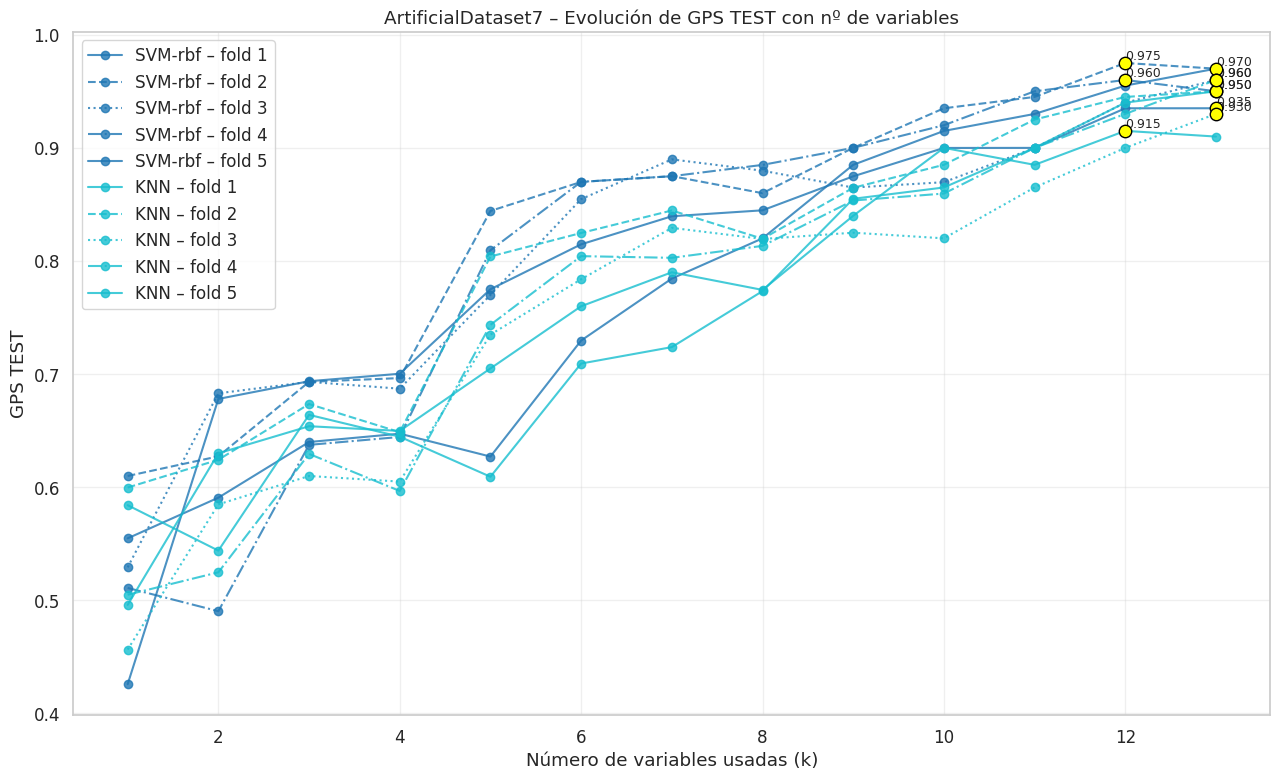

In [10]:
plot_incremental_performance(perf, importances_all, dataset="ArtificialDataset7", measure="gps_test")

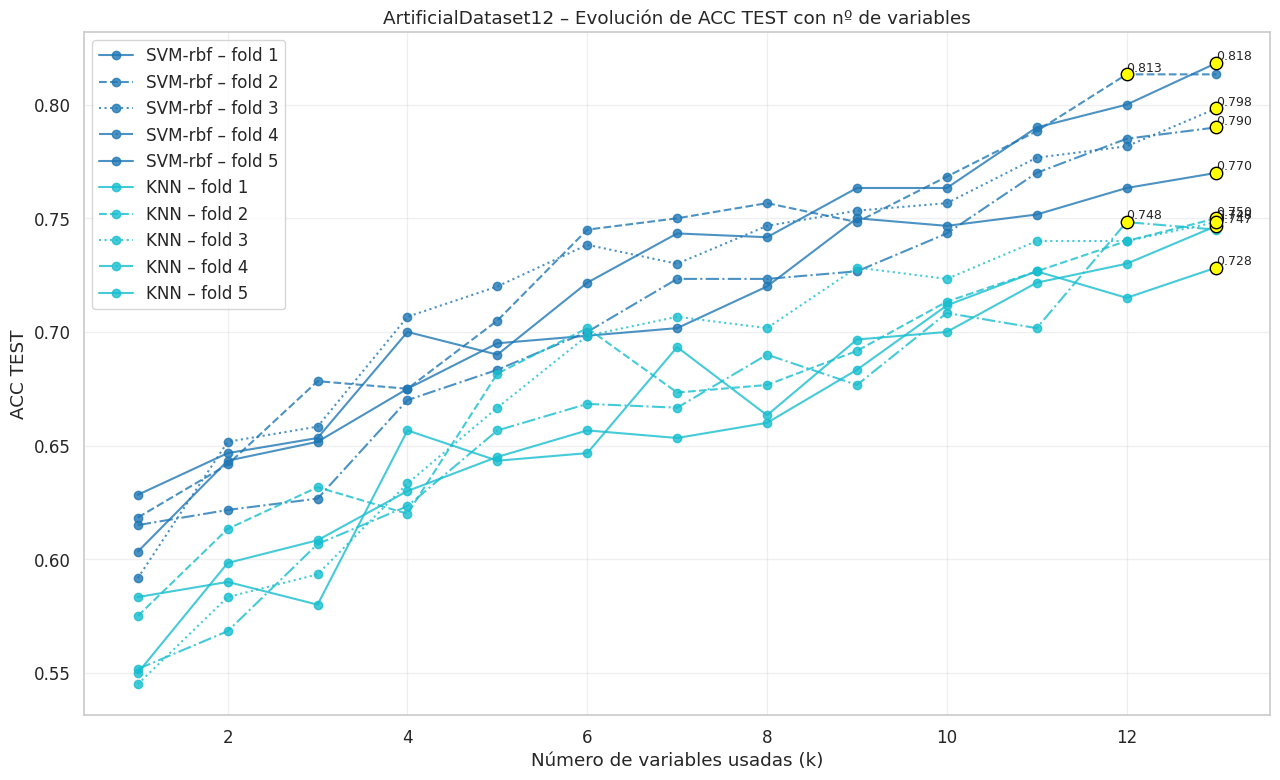

In [11]:
path_csv = 'Results_FS_Distributed_CV/ArtificialDataset12_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv'
importances_dict = load_importances_per_fold(path_csv)
importances_all = pd.concat([v["kDN_importances_norm"] for v in importances_dict.values()],ignore_index=True)

dfs = []
for fold, v in importances_dict.items():
    df = v["kDN_importances_norm"].copy()
    df["fold"] = fold
    dfs.append(df)

importances_all = pd.concat(dfs, ignore_index=True)
perf = pd.read_csv('Results_FS_Distributed_CV/ArtificialDataset12_OutHigh_EvolutivePerformance.csv')

plot_incremental_performance(perf, importances_all,dataset="ArtificialDataset12",measure="acc_test")

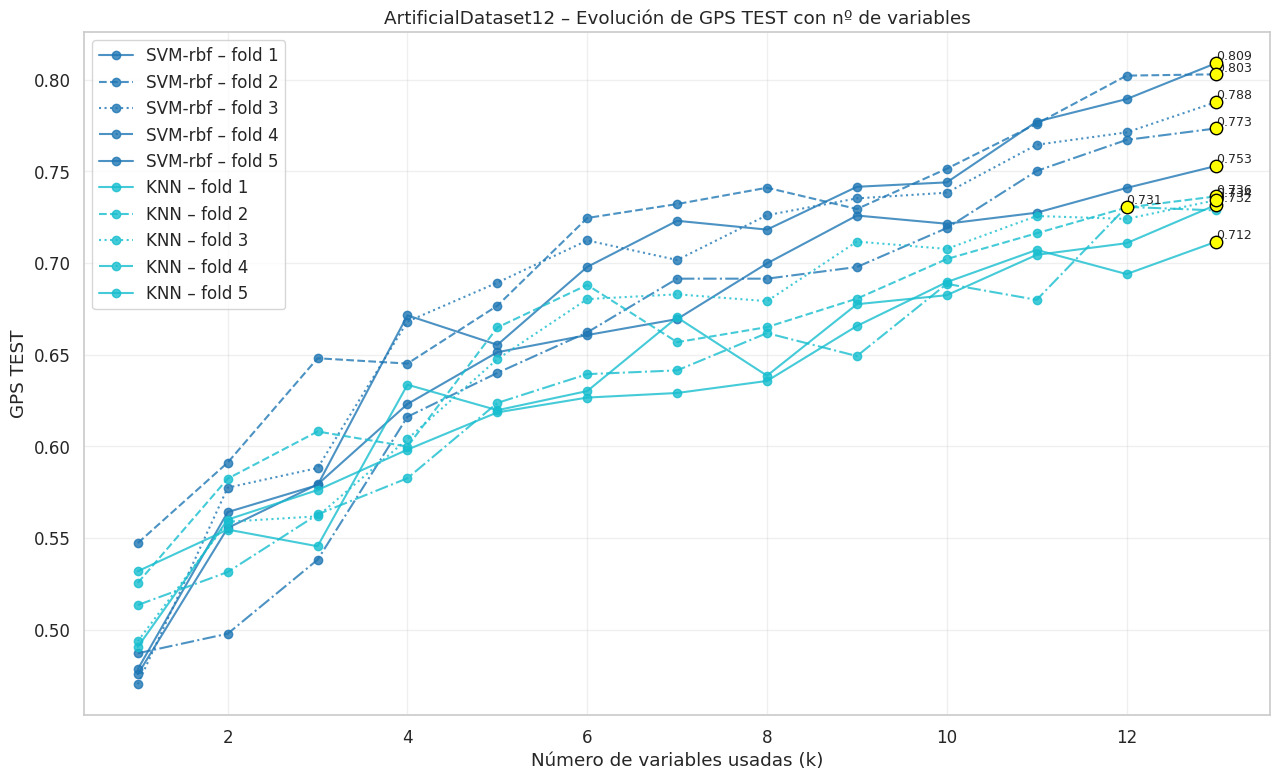

In [12]:
plot_incremental_performance(perf, importances_all, dataset="ArtificialDataset12", measure="gps_test")

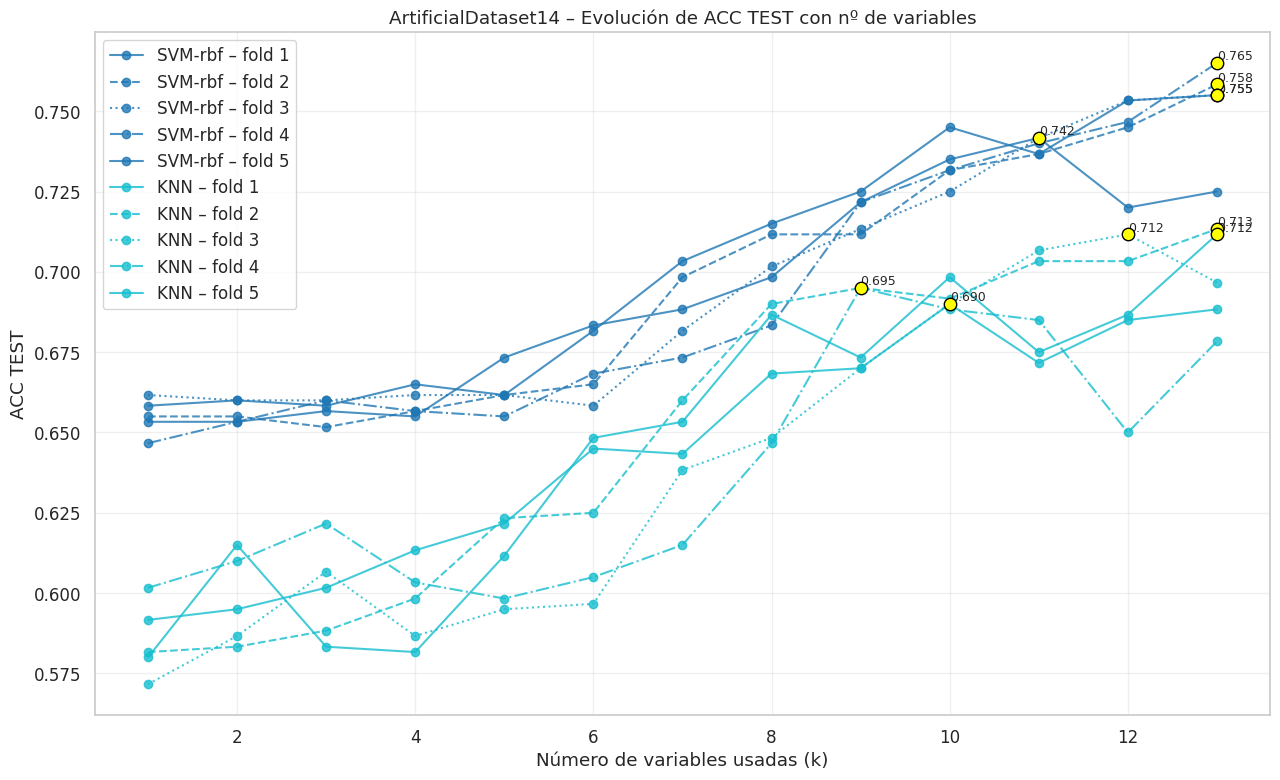

In [13]:
path_csv = 'Results_FS_Distributed_CV/ArtificialDataset14_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv'
importances_dict = load_importances_per_fold(path_csv)
importances_all = pd.concat([v["kDN_importances_norm"] for v in importances_dict.values()],ignore_index=True)

dfs = []
for fold, v in importances_dict.items():
    df = v["kDN_importances_norm"].copy()
    df["fold"] = fold
    dfs.append(df)

importances_all = pd.concat(dfs, ignore_index=True)
perf = pd.read_csv('Results_FS_Distributed_CV/ArtificialDataset14_OutHigh_EvolutivePerformance.csv')

plot_incremental_performance(perf, importances_all,dataset="ArtificialDataset14",measure="acc_test")

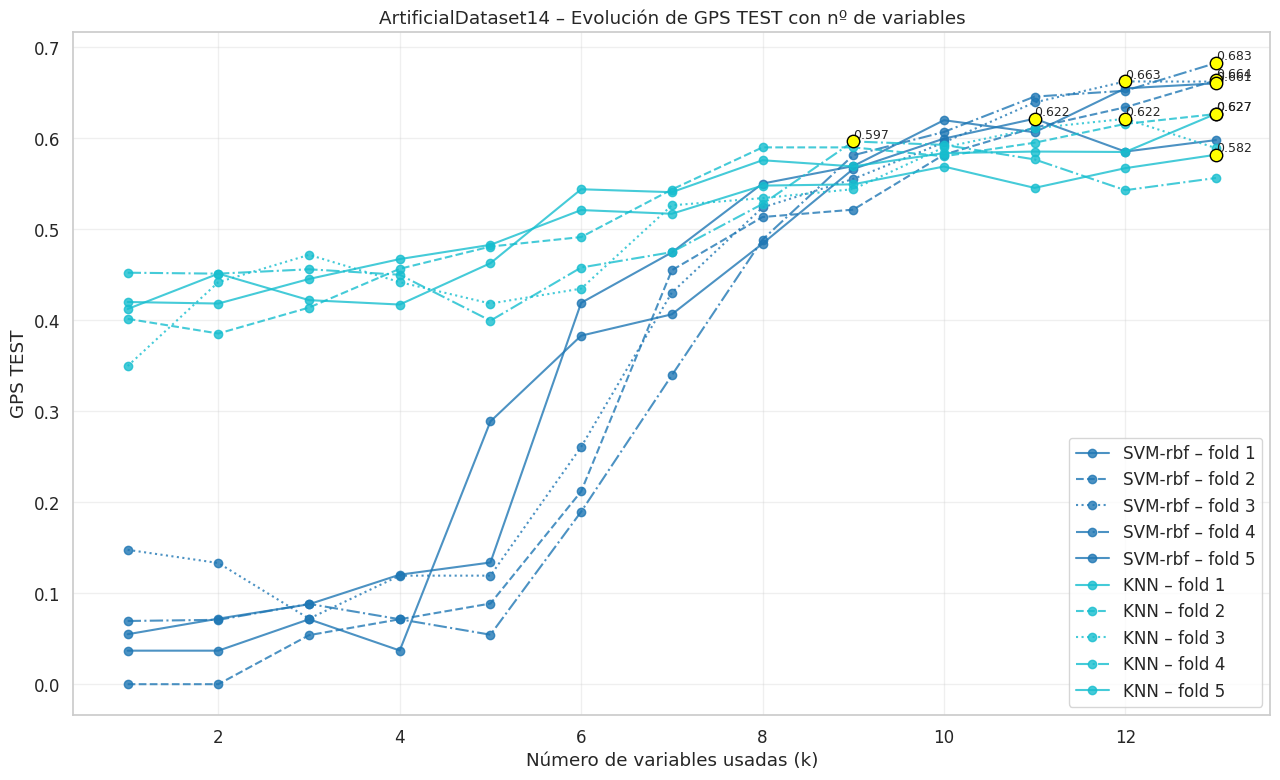

In [14]:
plot_incremental_performance(perf, importances_all, dataset="ArtificialDataset14", measure="gps_test")

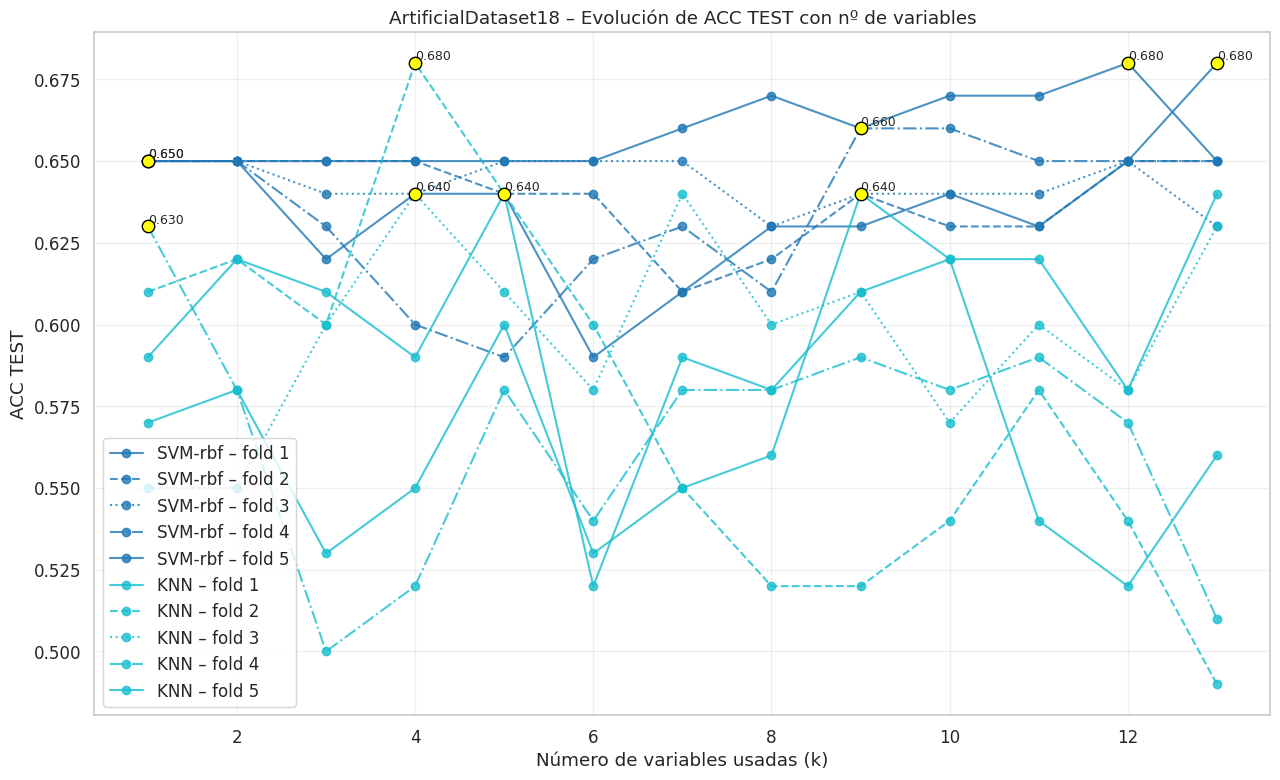

In [15]:
path_csv = 'Results_FS_Distributed_CV/ArtificialDataset18_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv'
importances_dict = load_importances_per_fold(path_csv)
importances_all = pd.concat([v["kDN_importances_norm"] for v in importances_dict.values()],ignore_index=True)

dfs = []
for fold, v in importances_dict.items():
    df = v["kDN_importances_norm"].copy()
    df["fold"] = fold
    dfs.append(df)

importances_all = pd.concat(dfs, ignore_index=True)
perf = pd.read_csv('Results_FS_Distributed_CV/ArtificialDataset18_OutHigh_EvolutivePerformance.csv')

plot_incremental_performance(perf, importances_all,dataset="ArtificialDataset18",measure="acc_test")

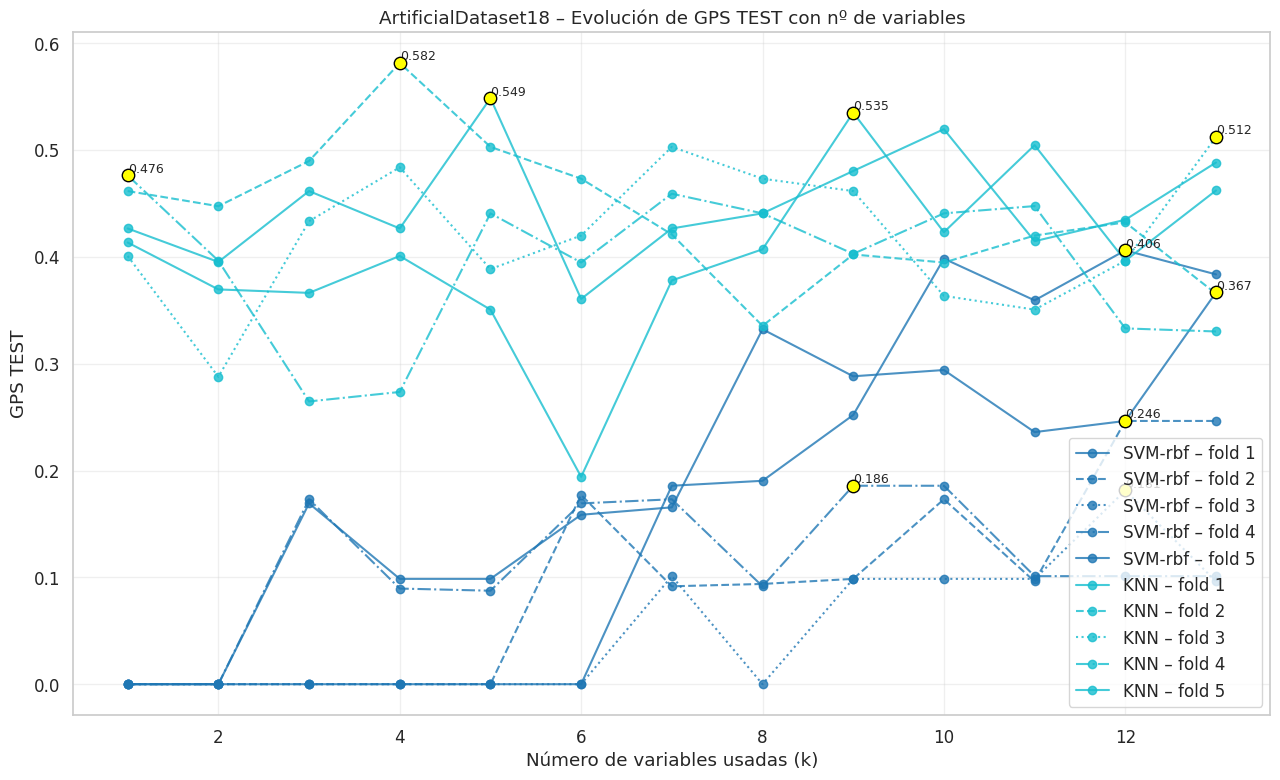

In [16]:
plot_incremental_performance(perf, importances_all, dataset="ArtificialDataset18", measure="gps_test")

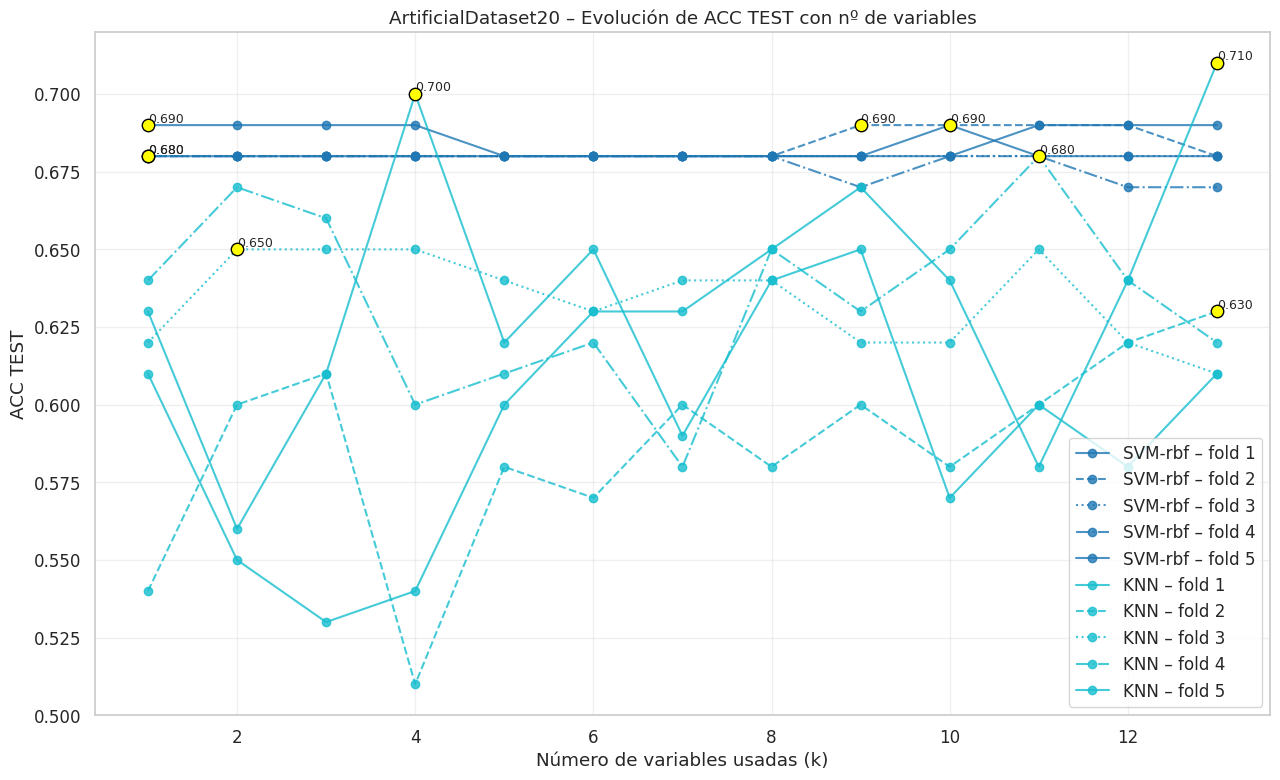

In [17]:
path_csv = 'Results_FS_Distributed_CV/ArtificialDataset20_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv'
importances_dict = load_importances_per_fold(path_csv)
importances_all = pd.concat([v["kDN_importances_norm"] for v in importances_dict.values()],ignore_index=True)

dfs = []
for fold, v in importances_dict.items():
    df = v["kDN_importances_norm"].copy()
    df["fold"] = fold
    dfs.append(df)

importances_all = pd.concat(dfs, ignore_index=True)
perf = pd.read_csv('Results_FS_Distributed_CV/ArtificialDataset20_OutHigh_EvolutivePerformance.csv')

plot_incremental_performance(perf, importances_all,dataset="ArtificialDataset20",measure="acc_test")

In [ ]:
plot_incremental_performance(perf, importances_all, dataset="ArtificialDataset20", measure="gps_test")

In [ ]:
path_csv = 'Results_FS_Distributed_CV/ArtificialDataset21_DistributedCVRandom_OutHigh_FeatureImportance_Folds.csv'
importances_dict = load_importances_per_fold(path_csv)
importances_all = pd.concat([v["kDN_importances_norm"] for v in importances_dict.values()],ignore_index=True)

dfs = []
for fold, v in importances_dict.items():
    df = v["kDN_importances_norm"].copy()
    df["fold"] = fold
    dfs.append(df)

importances_all = pd.concat(dfs, ignore_index=True)
perf = pd.read_csv('Results_FS_Distributed_CV/ArtificialDataset21_OutHigh_EvolutivePerformance.csv')

plot_incremental_performance(perf, importances_all,dataset="ArtificialDataset21",measure="acc_test")

In [ ]:
plot_incremental_performance(perf, importances_all, dataset="ArtificialDataset21", measure="gps_test")

ME QUEDO AQUÍ
## Estudio variables con "importancia" negativa

In [32]:
dataset_name = 'ArtificialDataset2'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=10,n_noise=2,
                                         n_redundant_linear=4,n_redundant_nonlinear=2,
                                    flip_y=0, class_sep = 0.6, n_clusters_per_class=1 , weights=[0.5],
                                                     random_state=0,noise_std=0.01)

csv_path = "Results_FS_Distributed/ArtificialDataset2_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,0,0,0.0,0,0
1,N1_importances_norm,2,0,100.0,0,0
2,kDN_importances_norm,2,0,100.0,0,0


In [33]:
### Dataset 3
dataset_name = 'ArtificialDataset3'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=25,n_noise=5,
                                         n_redundant_linear=7,n_redundant_nonlinear=8,
                                         flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=0,noise_std=0.05)

csv_path = "Results_FS_Distributed/ArtificialDataset3_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,6,33.33,50.0,0,16.67
1,N1_importances_norm,3,0.00,100.0,0,0.00
2,kDN_importances_norm,4,0.00,100.0,0,0.00


In [34]:
#### Dataset 7
dataset_name = 'ArtificialDataset7'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=20,n_noise=10,
                                         n_redundant_linear=10,n_redundant_nonlinear=10,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=589,noise_std=0.05)

csv_path = "Results_FS_Distributed/ArtificialDataset7_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,10,10.0,70.0,0,20.0
1,N1_importances_norm,9,0.0,100.0,0,0.0
2,kDN_importances_norm,10,0.0,100.0,0,0.0


In [35]:
#### Dataset 8
dataset_name = 'ArtificialDataset8'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=1000,n_informative=40,n_noise=15,
                                         n_redundant_linear=15,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=86785,noise_std=0.1)

csv_path = "Results_FS_Distributed/ArtificialDataset8_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,17,23.53,58.82,5.88,11.76
1,N1_importances_norm,16,18.75,68.75,0.00,12.50
2,kDN_importances_norm,16,12.50,75.00,0.00,12.50


In [36]:
#### Dataset 10
dataset_name = 'ArtificialDataset10'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=2000,n_informative=6,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=0.8, n_clusters_per_class=2, weights=[0.3],
                                                     random_state=959,noise_std=0.3)

csv_path = "Results_FS_Distributed/ArtificialDataset10_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,20,0,100.0,0,0
1,N1_importances_norm,19,0,100.0,0,0
2,kDN_importances_norm,20,0,100.0,0,0


In [37]:
#### Dataset 11
dataset_name = 'ArtificialDataset11'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=20,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=0.6, n_clusters_per_class=1, weights=[0.4],
                                                     random_state=959,noise_std=0.1)

csv_path = "Results_FS_Distributed/ArtificialDataset11_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,18,0,94.44,0,5.56
1,N1_importances_norm,20,0,100.00,0,0.00
2,kDN_importances_norm,19,0,100.00,0,0.00


In [38]:
#### Dataset 12
dataset_name = 'ArtificialDataset12'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=25,n_noise=30,
                                         n_redundant_linear=30,n_redundant_nonlinear=30,
                                        flip_y=0.2, class_sep=0.9, n_clusters_per_class=1, weights=[0.4],
                                                     random_state=987,noise_std=0.5)

csv_path = "Results_FS_Distributed/ArtificialDataset12_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,31,12.9,70.97,3.23,12.90
1,N1_importances_norm,19,0.0,94.74,0.00,5.26
2,kDN_importances_norm,29,0.0,89.66,0.00,10.34


In [39]:
# #### Dataset 14
dataset_name = 'ArtificialDataset14'
X, y, dict_info_feature = generate_synthetic_dataset(n_samples=3000,n_informative=30,n_noise=40,
                                         n_redundant_linear=30,n_redundant_nonlinear=40,
                                        flip_y=0.2, class_sep=0.6, n_clusters_per_class=2, weights=[0.3],
                                                     random_state=95,noise_std=0.5)

csv_path = "Results_FS_Distributed/ArtificialDataset14_ComplexityRandomDistributed.csv"
summary_neg = analyze_negative_importances(csv_path, dict_info_feature)
summary_neg

,measure,n_negatives,pct_informative,pct_noise,pct_redundant_linear,pct_redundant_nonlinear
0,Hostility_importances_norm,35,11.43,71.43,8.57,8.57
1,N1_importances_norm,32,12.50,68.75,6.25,12.50
2,kDN_importances_norm,38,5.26,73.68,0.00,21.05
